In [74]:
# Core
import numpy as np
import pandas as pd
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# NLTK for stopword removal
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


[nltk_data] Downloading package stopwords to
[nltk_data]   Package stopwords is already up-to-date!


In [75]:
file_path = "../data/imdb_labelled.txt"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["text", "label"]
)


In [76]:
df["label"].value_counts()


label
1    386
0    362
Name: count, dtype: int64

In [77]:
def find_unusual_characters(text_series):
    unusual_chars = set()
    for text in text_series:
        for ch in str(text):
            if ord(ch) > 127:  # non-ASCII
                unusual_chars.add(ch)
    return unusual_chars

unusual_before = find_unusual_characters(df["text"])
print("Unusual (non-ASCII) characters BEFORE cleaning:", unusual_before)


Unusual (non-ASCII) characters BEFORE cleaning: {'é', '\x85', '\x96', '\x97', 'å'}


In [78]:
def clean_text(text):
    text = str(text).lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # keep letters and numbers only (this prevents word merging)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # collapse spaces BEFORE stopword filtering
    text = re.sub(r"\s+", " ", text).strip()

    # remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)



In [79]:
df["clean_text"] = df["text"].apply(clean_text)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

sequences = tokenizer.texts_to_sequences(df["clean_text"])
lengths = [len(seq) for seq in sequences]


In [80]:
unusual_after = find_unusual_characters(df["clean_text"])
print("Unusual (non-ASCII) characters AFTER cleaning:", unusual_after)


Unusual (non-ASCII) characters AFTER cleaning: set()


In [81]:
temp_tokenizer = Tokenizer(oov_token="<OOV>")
temp_tokenizer.fit_on_texts(df["clean_text"])
temp_sequences = temp_tokenizer.texts_to_sequences(df["clean_text"])

lengths = [len(seq) for seq in temp_sequences]

print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))
print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("95th percentile length:", np.percentile(lengths, 95))


Min length: 1
Max length: 781
Mean length: 10.3475935828877
Median length: 6.0
95th percentile length: 19.0


In [82]:
# How many reviews are longer than 50 tokens?
long_over_50 = sum(l > 50 for l in lengths)
print("Reviews > 50 tokens:", long_over_50)
print(f"This represents {long_over_50/len(lengths)*100:.1f}% of the dataset")

# Top 5 longest lengths
print("\nTop 5 longest lengths:")
print(sorted(lengths, reverse=True)[:5])

Reviews > 50 tokens: 5
This represents 0.7% of the dataset

Top 5 longest lengths:
[781, 485, 459, 150, 116]


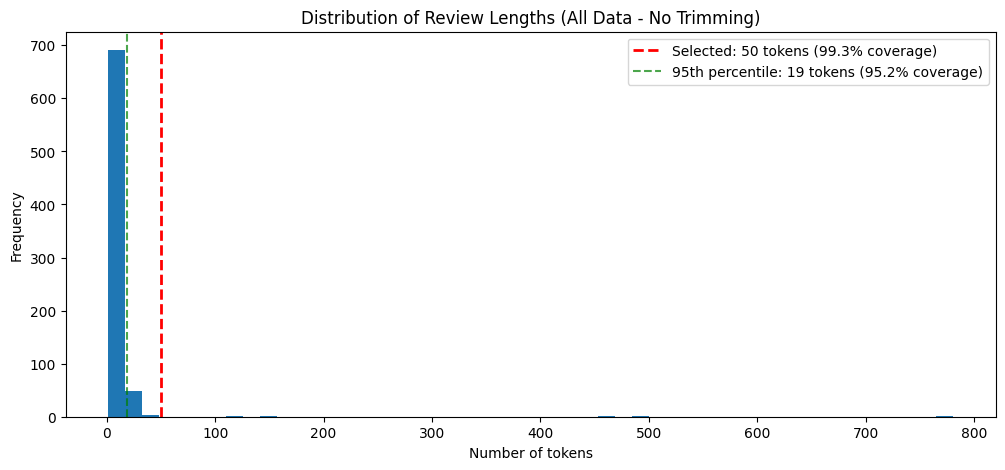

Note: Most reviews (743/748) are ≤ 50 tokens,
but a few outliers extend up to 781 tokens, making the distribution hard to read.


In [83]:
# Histogram with ALL lengths (no trimming) - shows the full distribution
plt.figure(figsize=(12, 5))
plt.hist(lengths, bins=50)
plt.title("Distribution of Review Lengths (All Data - No Trimming)")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.axvline(x=50, color='r', linestyle='--', linewidth=2, label='Selected: 50 tokens (99.3% coverage)')
plt.axvline(x=int(np.percentile(lengths, 95)), color='g', linestyle='--', alpha=0.7, label=f'95th percentile: 19 tokens (95.2% coverage)')
plt.legend()
plt.show()

print(f"Note: Most reviews ({len([l for l in lengths if l <= 50])}/{len(lengths)}) are ≤ 50 tokens,")
print(f"but a few outliers extend up to {max(lengths)} tokens, making the distribution hard to read.")

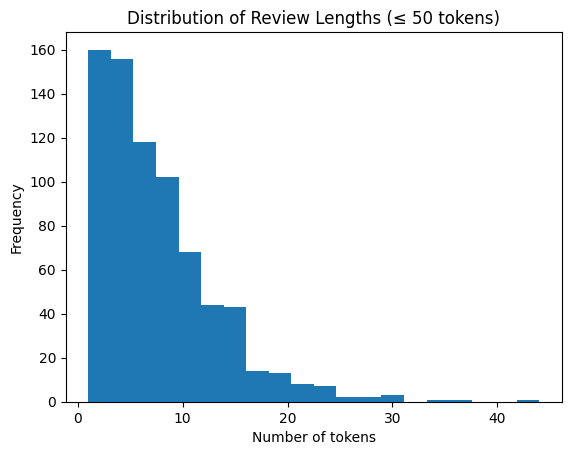

In [84]:
# Histogram zoomed in to more typical lengths (e.g., <= 50 tokens)
trimmed_lengths = [l for l in lengths if l <= 50]

plt.figure()
plt.hist(trimmed_lengths, bins=20)
plt.title("Distribution of Review Lengths (≤ 50 tokens)")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()


In [85]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for padding token

print("Vocabulary size:", vocab_size)


Vocabulary size: 2939


In [86]:
# Analyze different max sequence length options
print("Analysis of sequence length options:")
print(f"50th percentile (median): {int(np.percentile(lengths, 50))}")
print(f"75th percentile: {int(np.percentile(lengths, 75))}")
print(f"90th percentile: {int(np.percentile(lengths, 90))}")
print(f"95th percentile: {int(np.percentile(lengths, 95))}")
print(f"99th percentile: {int(np.percentile(lengths, 99))}")
print(f"\nReviews coverage at different lengths:")
for threshold in [19, 30, 50, 60, 100]:
    coverage = sum(l <= threshold for l in lengths) / len(lengths) * 100
    truncated = len(lengths) - sum(l <= threshold for l in lengths)
    print(f"  Length {threshold:3d}: {coverage:5.1f}% covered ({truncated:3d} reviews truncated)")


Analysis of sequence length options:
50th percentile (median): 6
75th percentile: 10
90th percentile: 15
95th percentile: 19
99th percentile: 33

Reviews coverage at different lengths:
  Length  19:  95.2% covered ( 36 reviews truncated)
  Length  30:  98.8% covered (  9 reviews truncated)
  Length  50:  99.3% covered (  5 reviews truncated)
  Length  60:  99.3% covered (  5 reviews truncated)
  Length 100:  99.3% covered (  5 reviews truncated)


In [ ]:
# Decision: Choosing max sequence length
# 
# After analyzing the distribution, I considered two options:
# 1. 95th percentile (19 tokens): Covers 95.2% of reviews, truncates 36 reviews (4.8%)
# 2. 50 tokens: Covers 99.3% of reviews, truncates only 5 reviews (0.7%)
#
# Rationale for choosing 50 tokens:
# - With a small dataset (748 reviews), losing 36 reviews to truncation (4.8%) is significant
# - 50 tokens provides 99.3% coverage, preserving nearly all information
# - The additional padding for shorter reviews is minimal computational overhead
# - Longer sequences allow the BiLSTM to capture more contextual information for sentiment
# - Only 5 reviews exceed 50 tokens, and these extreme outliers (up to 781 tokens) would 
#   be heavily truncated regardless of our choice
#
# Trade-off: Slightly more padding for short reviews vs. losing 4.8% of data
# Decision: Choose 50 tokens for maximum data preservation and context

max_sequence_len = 50
print(f"Selected max sequence length: {max_sequence_len} tokens")
print(f"This covers {sum(l <= max_sequence_len for l in lengths)/len(lengths)*100:.1f}% of reviews")
print(f"Reviews that will be truncated: {sum(l > max_sequence_len for l in lengths)}")


Selected max sequence length: 50 tokens
This covers 99.3% of reviews
Reviews that will be truncated: 5


In [ ]:
sequences = tokenizer.texts_to_sequences(df["clean_text"])

padded = pad_sequences(
    sequences,
    maxlen=max_sequence_len,
    padding="post",   
    truncating="post"
)

print("Padded shape:", padded.shape)


Padded shape: (748, 50)


In [89]:
example_index = 0
print("Original cleaned text:", df.loc[example_index, "clean_text"])
print("Padded sequence:\n", padded[example_index])


Original cleaned text: slow moving aimless movie distressed drifting young man
Padded sequence:
 [ 188  297 1086    2 1087 1088  298   70    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [90]:
X = padded
y = df["label"].values

# 80% train, 10% validation, 10% test (industry-like split)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 598
Validation samples: 75
Test samples: 75


In [91]:
# Save datasets as CSV files for submission
# Combine features (X) and labels (y) for each split

# Training set
train_df = pd.DataFrame(X_train)
train_df['label'] = y_train
train_df.to_csv('train_dataset.csv', index=False)
print(f"Training dataset saved: {train_df.shape[0]} samples, {train_df.shape[1]-1} features + 1 label")

# Validation set
val_df = pd.DataFrame(X_val)
val_df['label'] = y_val
val_df.to_csv('validation_dataset.csv', index=False)
print(f"Validation dataset saved: {val_df.shape[0]} samples, {val_df.shape[1]-1} features + 1 label")

# Test set
test_df = pd.DataFrame(X_test)
test_df['label'] = y_test
test_df.to_csv('test_dataset.csv', index=False)
print(f"Test dataset saved: {test_df.shape[0]} samples, {test_df.shape[1]-1} features + 1 label")

print("\nAll datasets saved successfully!")


Training dataset saved: 598 samples, 50 features + 1 label
Validation dataset saved: 75 samples, 50 features + 1 label
Test dataset saved: 75 samples, 50 features + 1 label

All datasets saved successfully!


In [92]:
embedding_dim = 100

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")   # binary output
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Build the model explicitly to ensure it's constructed before summary
model.build(input_shape=(None, max_sequence_len))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 100)        │       293,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,909 (2.08 MB)

 Trainable params: 544,909 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5217 - loss: 0.6929 - val_accuracy: 0.5200 - val_loss: 0.6918
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5368 - loss: 0.6890 - val_accuracy: 0.6267 - val_loss: 0.6869
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7007 - loss: 0.6330 - val_accuracy: 0.6800 - val_loss: 0.6257
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9013 - loss: 0.3424 - val_accuracy: 0.6533 - val_loss: 1.0346
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9565 - loss: 0.1540 - val_accuracy: 0.6800 - val_loss: 0.6610


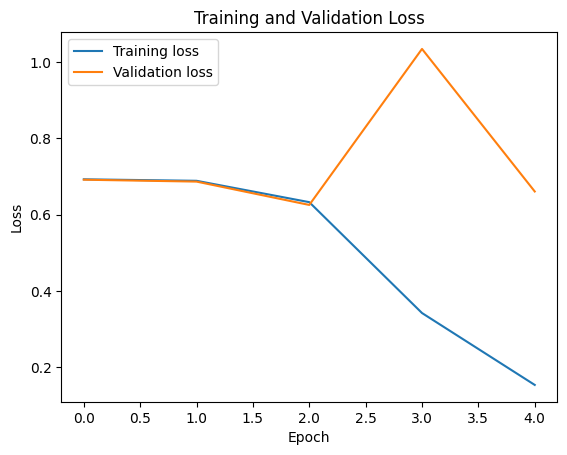

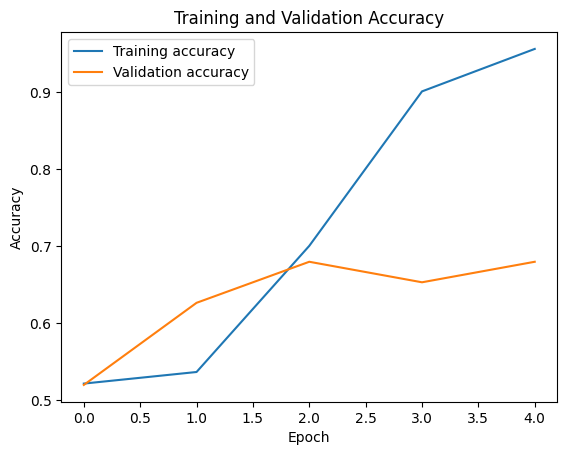

In [94]:
# Loss
plt.figure()
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [95]:
# Evaluate with Keras first
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Predictions for sklearn metrics
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nSklearn Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Test loss: 0.5792
Test accuracy: 0.7600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

Sklearn Metrics:
Accuracy : 0.7600
Precision: 0.8846
Recall   : 0.6053
F1 score : 0.7188

Classification Report:
              precision    recall  f1-score   support

           0     0.6939    0.9189    0.7907        37
           1     0.8846    0.6053    0.7188        38

    accuracy                         0.7600        75
   macro avg     0.7892    0.7621    0.7547        75
weighted avg     0.7905    0.7600    0.7542        75



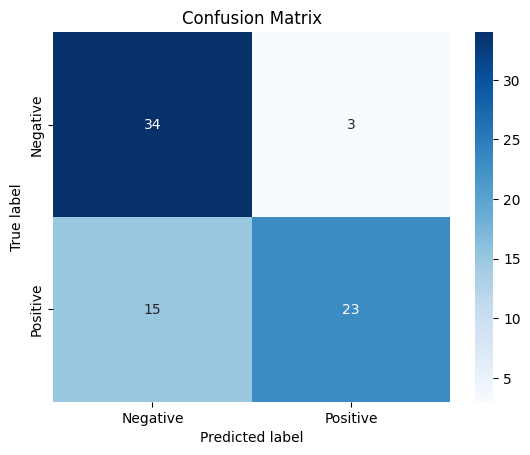

In [96]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()


In [97]:
model.save("imdb_sentiment_bilstm_model.keras")
print("Model saved as imdb_sentiment_bilstm_model.keras")


Model saved as imdb_sentiment_bilstm_model.keras
